📘 Task 2: Unemployment Analysis with Python

# 📊 Unemployment Analysis with Python

## Oasis Infobyte Data Science Internship

### Task 2

### Objective

The objective of this project is to analyze unemployment trends in India using Python. We will perform data cleaning, exploratory data analysis (EDA), time-series analysis, and compare unemployment before and after the COVID-19 pandemic.

# Table of Contents

1. Import Libraries
2. Load Dataset
3. Dataset Overview
4. Data Cleaning
5. Data Preprocessing
6. Exploratory Data Analysis (EDA)
7. Time Series Analysis
8. Top 10 States by Unemployment Rate
9. Correlation Analysis
10. COVID-19 Impact Analysis
11. Conclusion

# 1. Import Libraries

In this section, we import all the required Python libraries for data analysis and visualization.

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Improve plot appearance
sns.set_style("whitegrid")

# 2. Load Dataset

The unemployment dataset is loaded using Pandas.

In [39]:
df = pd.read_csv("../data/Unemployment in India.csv")

In [40]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


### Observation

The dataset contains unemployment-related information for different Indian states. Each row represents unemployment statistics for a particular state and date.

# 3 . Dataset Information

Before analysis, let's understand the dataset structure.

In [41]:
df.shape

(768, 7)

In [42]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Notice the spaces before the names.

Clean them first:

In [43]:
df.columns = df.columns.str.strip()

In [44]:
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


### Observation

The dataset contains multiple columns such as Region, Date, Estimated Unemployment Rate, Estimated Employed and Labour Participation Rate.

# 4 Data Cleaning

Now we check for missing values, duplicate records and data types.

In [46]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [47]:
df.duplicated().sum()

27

In [48]:
df.dtypes

Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                        object
dtype: object

### Observation

The dataset contains very few missing values. Duplicate records are checked before further analysis.

# 5 Data Preprocessing

Convert the Date column into datetime format.

In [49]:
df["Date"] = pd.to_datetime(df["Date"])

C:\Users\naren\AppData\Local\Temp\ipykernel_6032\936118274.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


In [50]:
df["Month"] = df["Date"].dt.month_name()

df["Year"] = df["Date"].dt.year

### Observation

The Date column is successfully converted into datetime format, allowing time-based analysis.

# Exploratory Data Analysis

We now begin exploring the unemployment data.

## 6.1 Region-wise Average Unemployment Rate

This analysis calculates the average unemployment rate for each region (state/UT) and compares them using a horizontal bar chart.

In [51]:
# Calculate average unemployment rate by region

region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
)

region_avg.head()

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Name: Estimated Unemployment Rate (%), dtype: float64

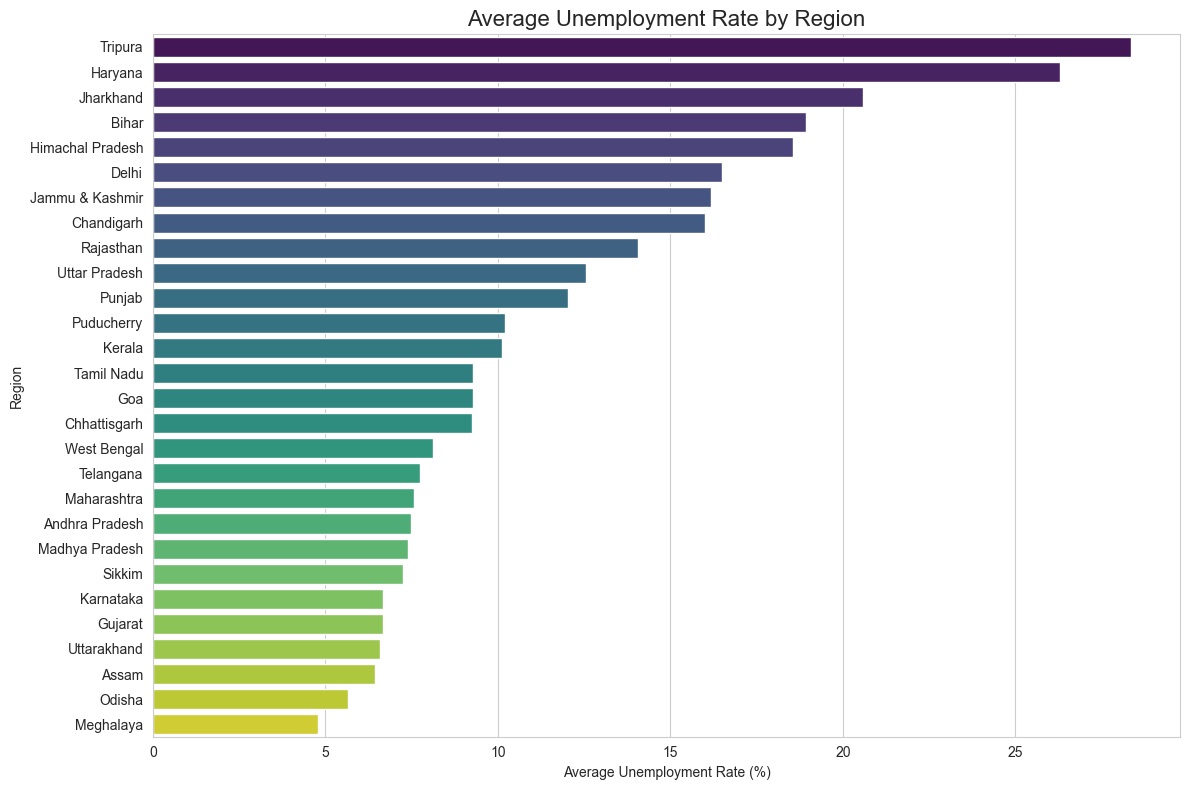

In [52]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=region_avg.values,
    y=region_avg.index,
    hue=region_avg.index,
    palette="viridis",
    legend=False
)

plt.title("Average Unemployment Rate by Region", fontsize=16)
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.savefig("../images/region_wise_unemployment.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- Tripura recorded the highest average unemployment rate among all regions.
- Haryana and Jharkhand also showed comparatively high unemployment.
- Meghalaya recorded one of the lowest average unemployment rates.
- There is a significant variation in unemployment across different regions of India.

## 6.2 Month-wise Average Unemployment Trend

This analysis examines how the average unemployment rate changes from month to month.## 6.2 Month-wise Average Unemployment Trend

This analysis examines how unemployment rates change over different months. It helps identify seasonal and economic fluctuations.

In [53]:
monthly_avg = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
      .mean()
)

monthly_avg

Month
April        23.641569
August        9.637925
December      9.497358
February      9.964717
January       9.950755
July          9.033889
June         10.553462
March        10.700577
May          16.646190
November      9.868364
October       9.900909
September     9.051731
Name: Estimated Unemployment Rate (%), dtype: float64

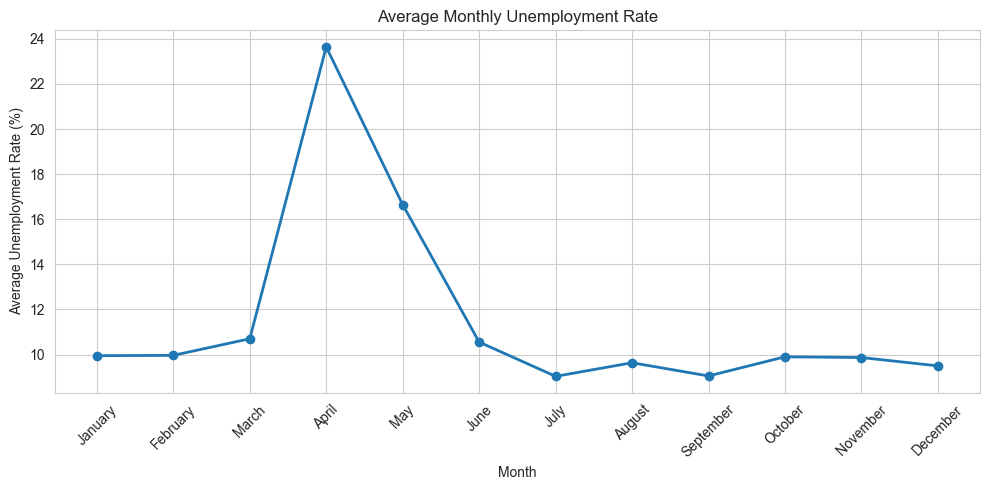

In [54]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_avg = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
      .mean()
      .reindex(month_order)
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.savefig("../images/monthly_trend.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- Monthly unemployment rates fluctuate over time.
- A sharp increase is visible during the pandemic period.
- Economic and seasonal factors contribute to changes in unemployment across different months.

# 7. Time Series Analysis

This section compares unemployment trends over time for three major Indian states.

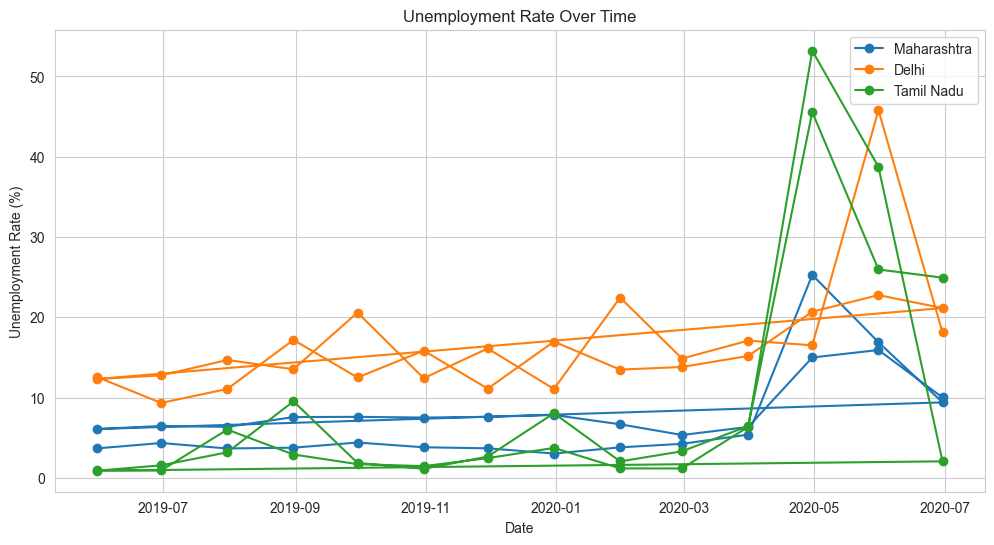

In [55]:
states = [
    "Maharashtra",
    "Delhi",
    "Tamil Nadu"
]

plt.figure(figsize=(12,6))

for state in states:

    state_data = df[df["Region"] == state]

    plt.plot(
        state_data["Date"],
        state_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=state
    )

plt.title("Unemployment Rate Over Time")

plt.xlabel("Date")

plt.ylabel("Unemployment Rate (%)")

plt.legend()

plt.grid(True)
plt.savefig("../images/time_series_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- Monthly unemployment fluctuates throughout the year.
- Certain months recorded noticeably higher unemployment rates.
- Seasonal and economic factors may influence these changes.

# 7. Time Series Analysis

This section compares unemployment trends over time for three major Indian states.

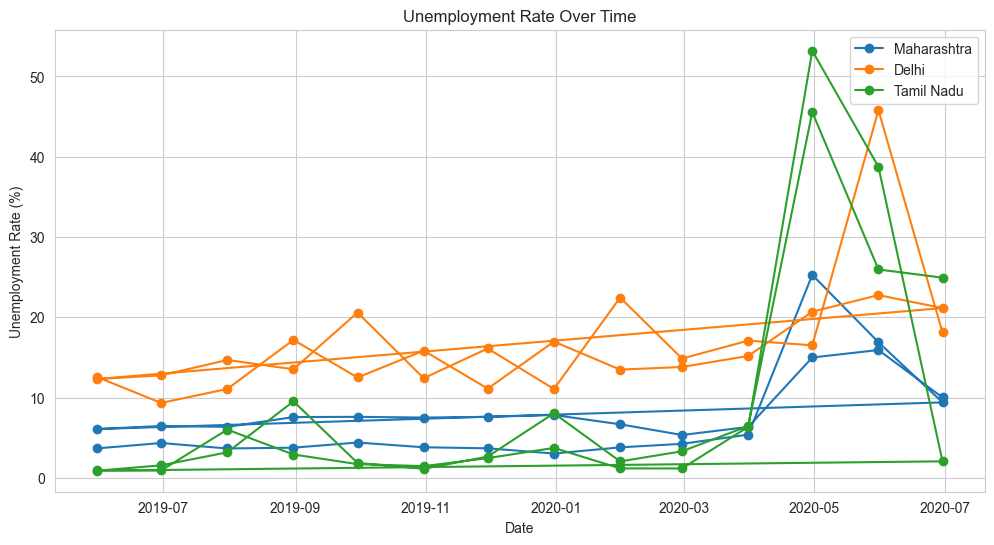

In [56]:
states = [
    "Maharashtra",
    "Delhi",
    "Tamil Nadu"
]

plt.figure(figsize=(12,6))

for state in states:

    state_data = df[df["Region"] == state]

    plt.plot(
        state_data["Date"],
        state_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=state
    )

plt.title("Unemployment Rate Over Time")

plt.xlabel("Date")

plt.ylabel("Unemployment Rate (%)")

plt.legend()

plt.grid(True)

plt.show()

### Observation

- The unemployment rate changes over time in all three selected states.
- A noticeable increase is observed during the COVID-19 lockdown period.
- Different states recovered at different rates after the pandemic.

# 8. Top 10 States with Highest Average Unemployment Rate

In this section, we identify the top 10 states having the highest average unemployment rate throughout the dataset.

In [57]:
# Top 10 states with highest average unemployment rate

top10_states = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

top10_states

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

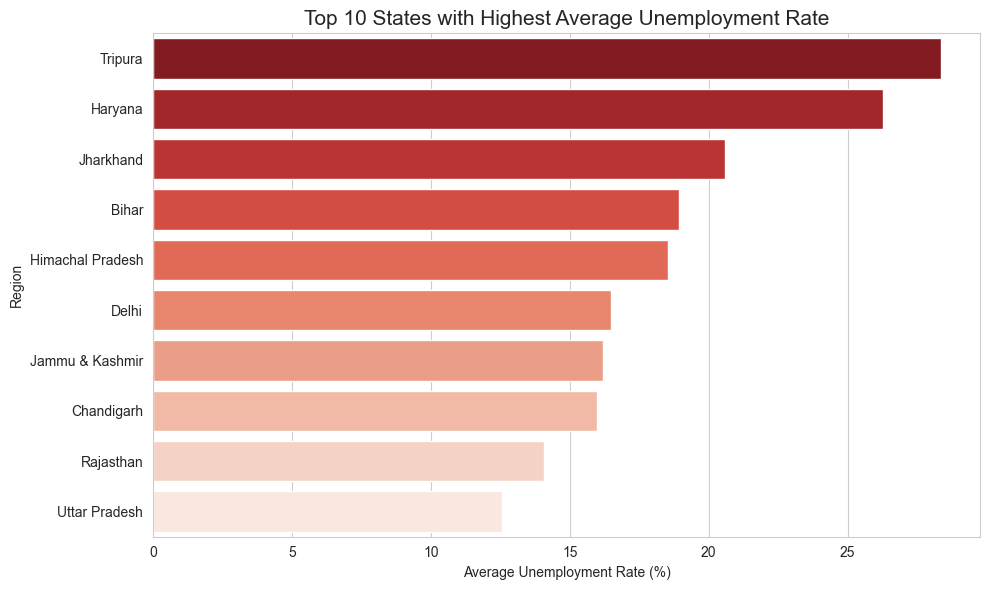

In [64]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10_states.values,
    y=top10_states.index,
    hue=top10_states.index,
    palette="Reds_r",
    legend=False
)

plt.title("Top 10 States with Highest Average Unemployment Rate", fontsize=15)
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig("../images/top10_states.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Tripura recorded the highest average unemployment rate.
- Haryana and Jharkhand also experienced high unemployment.
- These regions may require stronger employment generation policies.

# 9. Correlation Analysis

This section examines the relationship between unemployment rate, employment, and labour participation rate using a correlation heatmap.

In [59]:
correlation = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

correlation

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


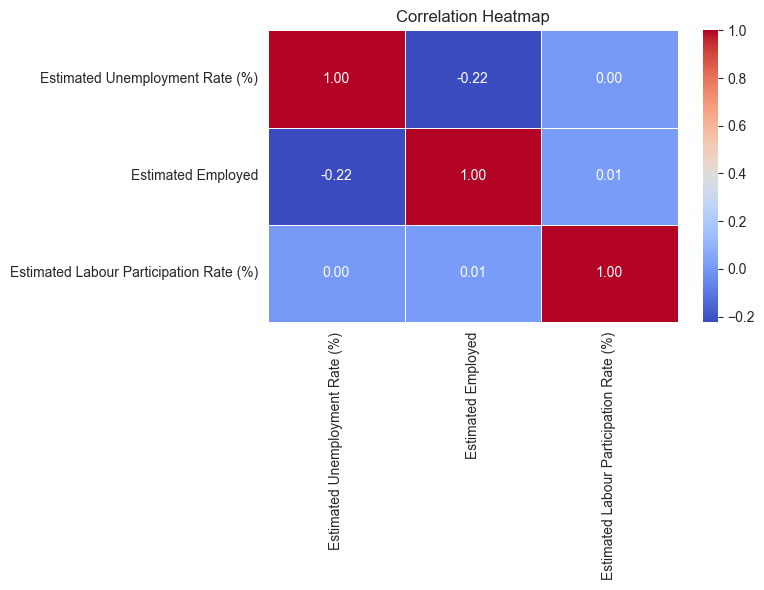

In [60]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- The unemployment rate has a negative correlation with the estimated employed population.
- Labour participation rate shows a moderate relationship with unemployment.
- The heatmap helps understand the strength of relationships between key employment indicators.

# 10. COVID-19 Impact Analysis

The COVID-19 pandemic significantly affected employment across India. In this section, we compare the average unemployment rate before and after the nationwide lockdown announced on 25 March 2020.

In [61]:
# Split dataset into pre-COVID and post-COVID periods

pre_covid = df[df["Date"] < "2020-03-25"]

post_covid = df[df["Date"] >= "2020-03-25"]

In [62]:
comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "Post-COVID"],
    "Average Unemployment Rate (%)": [
        pre_covid["Estimated Unemployment Rate (%)"].mean(),
        post_covid["Estimated Unemployment Rate (%)"].mean()
    ]
})

comparison

,Period,Average Unemployment Rate (%)
0,Pre-COVID,9.509534
1,Post-COVID,17.774363


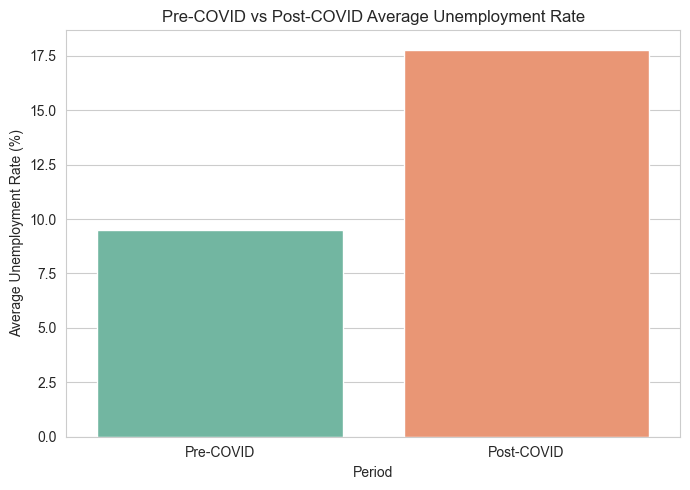

In [63]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment Rate (%)",
    hue="Period",
    palette="Set2",
    legend=False
)

plt.title("Pre-COVID vs Post-COVID Average Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()

plt.savefig("../images/covid_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- The average unemployment rate increased after the COVID-19 outbreak.
- The nationwide lockdown had a significant impact on employment across India.
- The comparison clearly highlights the economic disruption caused by the pandemic.

# 11. Conclusion

## Project Summary

This project analyzed unemployment trends in India using Python and various data visualization techniques.

### Key Findings

- Regional unemployment rates vary significantly across India.
- Tripura recorded the highest average unemployment rate in the dataset.
- Monthly unemployment trends show noticeable fluctuations.
- The COVID-19 pandemic caused a significant rise in unemployment.
- Correlation analysis revealed relationships between unemployment rate, employment, and labour participation rate.
- Data visualization made it easier to identify regional and temporal unemployment patterns.